In [1]:
import nltk

In [2]:
import pandas as pd

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to resolve LookupError during tokenization
nltk.download('averaged_perceptron_tagger_eng') # Added to resolve LookupError for POS tagging

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [6]:
from google.colab import files

print('Please upload the cookie_reviews.csv file:')
uploaded = files.upload()

Please upload the cookie_reviews.csv file:


Saving cookie_reviews.csv to cookie_reviews.csv


In [8]:
data = pd.read_csv('cookie_reviews.csv')
data.head()

,user_id,stars,reviews
0,A368Z46FIKHSEZ,5,I love these cookies! Not only are they healt...
1,A1JAPP1CXRG57A,5,Quaker Soft Baked Oatmeal Cookies with raisins...
2,A2Z9JNXPIEL2B9,5,I am usually not a huge fan of oatmeal cookies...
3,A31CYJQO3FL586,5,I participated in a product review that includ...
4,A2KXQ2EKFF3K2G,5,My kids loved these. I was very pleased to giv...


## Question 1 ##
* Determine how many reviews there are in total.
* Determine the percent of 1, 2, 3, 4 and 5 star reviews.
* Determine the distribution of character lengths for the reviews, by listing the values and by plotting a histogram.

In [9]:
# Determine how many reviews there are in total.
total_review=len(data)
print("Total number of reviews:",total_review)

Total number of reviews: 913


In [10]:
# Determine the percent of 1, 2, 3, 4 and 5 star reviews.
star_review_counts=data['stars'].value_counts().sort_index()
start_review_percentages=(star_review_counts/total_review)*100

print("Percent of star reviews:")
print(start_review_percentages.round(2).astype(str)+'%')

Percent of star reviews:
stars
1     0.44%
2     1.31%
3     6.13%
4    23.77%
5    68.35%
Name: count, dtype: object


In [11]:
# Determine the distribution of character lengths for the reviews.
data['review_length'] = data['reviews'].apply(len)

print("Character length distribution (descriptive statistics):")
display(data['review_length'].describe())

Character length distribution (descriptive statistics):


,review_length
count,913.000000
mean,284.684556
std,247.156401
min,87.000000
25%,146.000000
50%,204.000000
75%,324.000000
max,3535.000000


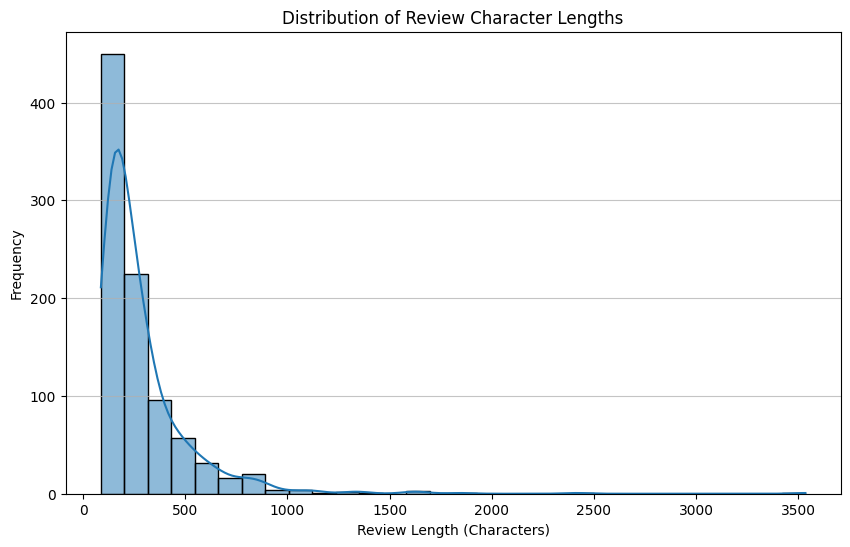

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram of character lengths.
plt.figure(figsize=(10, 6))
sns.histplot(data['review_length'], bins=30, kde=True)
plt.title('Distribution of Review Character Lengths')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Question 2 ##
* Apply the following preprocessing steps:

     1. Remove all words that contain numbers
     2. Make all the text lowercase
     3. Remove punctuation
     4. Tokenize the reviews into words
     
  Hint #1: Use regular expressions.
  
  Hint #2: The cookie review in the second row has numbers, upper case letters and punctuation. You can use it to test out your regular expressions.
     
     
* Find the most common words.
* Determine the word length distribution over the entire corpus.

In [13]:
#### Preprocessing Steps
import re

def preprocess_review(text):
    # 1. Remove all words that contain numbers
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    # 2. Make all the text lowercase
    text = text.lower()
    # 3. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

# Create a new column for preprocessed reviews
data['preprocessed_reviews'] = data['reviews'].apply(preprocess_review)

print("Original Review Example:")
print(data['reviews'].iloc[1])
print("\nPreprocessed Review Example (without tokenization yet):")
print(data['preprocessed_reviews'].iloc[1])

Original Review Example:
Quaker Soft Baked Oatmeal Cookies with raisins are a delicious treat, great for anytime of day.  For example:<br /><br />--at breakfast, I had one with a large banana and a cup of coffee, and felt I'd had a relatively "healthy" start to the day.<br /><br />--the next day at lunch, following a tuna sandwich, I had one with a glass of milk, and was satisfied enough to not need a snack before dinner at 6:30.<br /><br />--the following night, after dinner, I had one with the remainder of my glass of wine. (Delicious!) And again, didn't feel the need to snack later in the evening.<br /><br />Each cookie is individually packaged, and their texture is soft and moist, with just the right amount of sweetness. Natural flavors used in the making are Cinnamon and All Spice.  These flavorings give the cookies a real old-fashioned, homemade taste.<br /><br />Nutritionally, the cookies have 170 calories each, 1.5g saturated fat, 150 mg sodium, and 12g sugar. They also have 2g

In [14]:
from nltk.tokenize import word_tokenize

# 4. Tokenize the preprocessed reviews into words
data['tokenized_reviews'] = data['preprocessed_reviews'].apply(word_tokenize)

print("Tokenized Review Example:")
print(data['tokenized_reviews'].iloc[1])

Tokenized Review Example:
['quaker', 'soft', 'baked', 'oatmeal', 'cookies', 'with', 'raisins', 'are', 'a', 'delicious', 'treat', 'great', 'for', 'anytime', 'of', 'day', 'for', 'examplebr', 'br', 'at', 'breakfast', 'i', 'had', 'one', 'with', 'a', 'large', 'banana', 'and', 'a', 'cup', 'of', 'coffee', 'and', 'felt', 'id', 'had', 'a', 'relatively', 'healthy', 'start', 'to', 'the', 'daybr', 'br', 'the', 'next', 'day', 'at', 'lunch', 'following', 'a', 'tuna', 'sandwich', 'i', 'had', 'one', 'with', 'a', 'glass', 'of', 'milk', 'and', 'was', 'satisfied', 'enough', 'to', 'not', 'need', 'a', 'snack', 'before', 'dinner', 'at', 'br', 'br', 'the', 'following', 'night', 'after', 'dinner', 'i', 'had', 'one', 'with', 'the', 'remainder', 'of', 'my', 'glass', 'of', 'wine', 'delicious', 'and', 'again', 'didnt', 'feel', 'the', 'need', 'to', 'snack', 'later', 'in', 'the', 'eveningbr', 'br', 'each', 'cookie', 'is', 'individually', 'packaged', 'and', 'their', 'texture', 'is', 'soft', 'and', 'moist', 'with', '

In [15]:
### Most Common Words
from collections import Counter

# Flatten the list of tokenized words
all_words = [word for sublist in data['tokenized_reviews'] for word in sublist]

# Find the most common words
common_words = Counter(all_words).most_common(20)

print("Top 20 most common words after initial preprocessing:")
for word, count in common_words:
    print(f"{word}: {count}")

Top 20 most common words after initial preprocessing:
i: 2003
and: 1748
the: 1645
a: 1303
to: 990
it: 930
my: 837
cookies: 835
cookie: 824
of: 780
are: 745
soft: 693
they: 685
these: 662
was: 662
for: 593
in: 559
this: 547
oatmeal: 479
is: 467


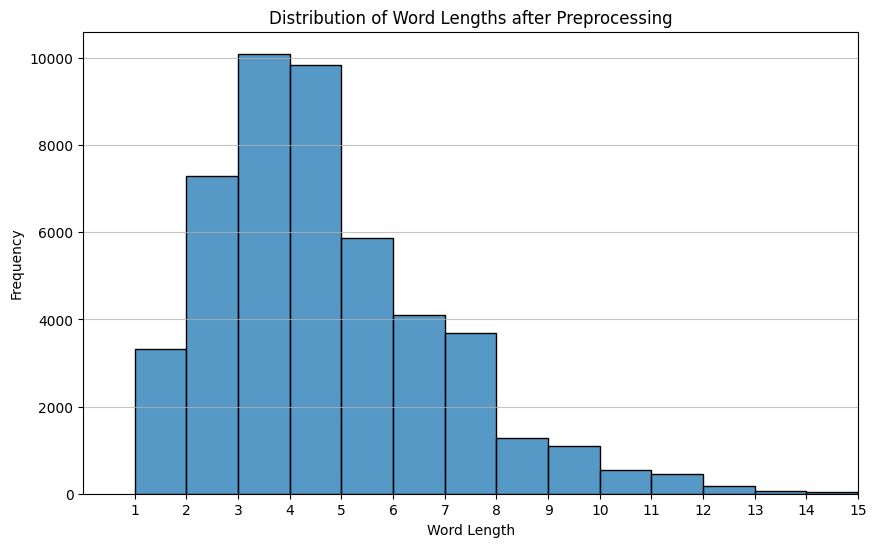

In [16]:
### Word Length Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Determine word lengths
word_lengths = [len(word) for word in all_words]

# Plot a histogram of word lengths
plt.figure(figsize=(10, 6))
sns.histplot(word_lengths, bins=range(1, max(word_lengths) + 2), kde=False)
plt.title('Distribution of Word Lengths after Preprocessing')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.xticks(range(1, max(word_lengths) + 1, 1))
plt.xlim(0, 15) # Limiting x-axis for better visualization of common lengths
plt.grid(axis='y', alpha=0.75)
plt.show()

## Question 3 ##
* Apply the following preprocessing techniques:

     * Remove stopwords
     * Perform parts of speech tagging
     * Perform stemming
     * Optional: Perform lemmatization

  Recommendation: Create a new column in your data set for every preprocessing technique you apply, so you can see the progression of the reviews text.


In [17]:
#Removing Stopwards
from nltk.corpus import stopwords

#Get English Stopwords
stop_words=set(stopwords.words('english'))

#Function to remove stopwords
def remove_stopwords(token):
    return [word for word in token if word not in stop_words]

# Apply stopword removal to the tokenized reviews
data['reviews_no_stopwords'] = data['tokenized_reviews'].apply(remove_stopwords)

print("Original Tokenized Review Example:")
print(data['tokenized_reviews'].iloc[1])
print("\nReview after Stopword Removal Example:")
print(data['reviews_no_stopwords'].iloc[1])

Original Tokenized Review Example:
['quaker', 'soft', 'baked', 'oatmeal', 'cookies', 'with', 'raisins', 'are', 'a', 'delicious', 'treat', 'great', 'for', 'anytime', 'of', 'day', 'for', 'examplebr', 'br', 'at', 'breakfast', 'i', 'had', 'one', 'with', 'a', 'large', 'banana', 'and', 'a', 'cup', 'of', 'coffee', 'and', 'felt', 'id', 'had', 'a', 'relatively', 'healthy', 'start', 'to', 'the', 'daybr', 'br', 'the', 'next', 'day', 'at', 'lunch', 'following', 'a', 'tuna', 'sandwich', 'i', 'had', 'one', 'with', 'a', 'glass', 'of', 'milk', 'and', 'was', 'satisfied', 'enough', 'to', 'not', 'need', 'a', 'snack', 'before', 'dinner', 'at', 'br', 'br', 'the', 'following', 'night', 'after', 'dinner', 'i', 'had', 'one', 'with', 'the', 'remainder', 'of', 'my', 'glass', 'of', 'wine', 'delicious', 'and', 'again', 'didnt', 'feel', 'the', 'need', 'to', 'snack', 'later', 'in', 'the', 'eveningbr', 'br', 'each', 'cookie', 'is', 'individually', 'packaged', 'and', 'their', 'texture', 'is', 'soft', 'and', 'moist', 

In [18]:
#### Part-of-Speech (POS) Tagging

from nltk import pos_tag

# Apply POS tagging
data['reviews_pos_tagged'] = data['reviews_no_stopwords'].apply(pos_tag)

print("Review after POS Tagging Example:")
print(data['reviews_pos_tagged'].iloc[1])

Review after POS Tagging Example:
[('quaker', 'NN'), ('soft', 'JJ'), ('baked', 'VBD'), ('oatmeal', 'JJ'), ('cookies', 'NNS'), ('raisins', 'VBZ'), ('delicious', 'JJ'), ('treat', 'NN'), ('great', 'JJ'), ('anytime', 'JJ'), ('day', 'NN'), ('examplebr', 'VB'), ('br', 'NN'), ('breakfast', 'IN'), ('one', 'CD'), ('large', 'JJ'), ('banana', 'NN'), ('cup', 'NN'), ('coffee', 'NN'), ('felt', 'VBD'), ('id', 'JJ'), ('relatively', 'RB'), ('healthy', 'JJ'), ('start', 'NN'), ('daybr', 'VB'), ('br', 'JJ'), ('next', 'JJ'), ('day', 'NN'), ('lunch', 'NN'), ('following', 'VBG'), ('tuna', 'NN'), ('sandwich', 'JJ'), ('one', 'CD'), ('glass', 'NN'), ('milk', 'NN'), ('satisfied', 'VBD'), ('enough', 'JJ'), ('need', 'NN'), ('snack', 'NN'), ('dinner', 'NN'), ('br', 'IN'), ('br', 'NN'), ('following', 'VBG'), ('night', 'NN'), ('dinner', 'NN'), ('one', 'CD'), ('remainder', 'NN'), ('glass', 'NN'), ('wine', 'VBP'), ('delicious', 'JJ'), ('didnt', 'NN'), ('feel', 'VB'), ('need', 'RB'), ('snack', 'RB'), ('later', 'RBR'), (

In [19]:
#### Stemming
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def apply_stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

# Apply stemming
data['reviews_stemmed'] = data['reviews_no_stopwords'].apply(apply_stemming)

print("Review after Stemming Example (using words without stopwords):")
print(data['reviews_stemmed'].iloc[1])

Review after Stemming Example (using words without stopwords):
['quaker', 'soft', 'bake', 'oatmeal', 'cooki', 'raisin', 'delici', 'treat', 'great', 'anytim', 'day', 'examplebr', 'br', 'breakfast', 'one', 'larg', 'banana', 'cup', 'coffe', 'felt', 'id', 'rel', 'healthi', 'start', 'daybr', 'br', 'next', 'day', 'lunch', 'follow', 'tuna', 'sandwich', 'one', 'glass', 'milk', 'satisfi', 'enough', 'need', 'snack', 'dinner', 'br', 'br', 'follow', 'night', 'dinner', 'one', 'remaind', 'glass', 'wine', 'delici', 'didnt', 'feel', 'need', 'snack', 'later', 'eveningbr', 'br', 'cooki', 'individu', 'packag', 'textur', 'soft', 'moist', 'right', 'amount', 'sweet', 'natur', 'flavor', 'use', 'make', 'cinnamon', 'spice', 'flavor', 'give', 'cooki', 'real', 'oldfashion', 'homemad', 'tastebr', 'br', 'nutrit', 'cooki', 'calori', 'satur', 'fat', 'mg', 'sodium', 'sugar', 'also', 'protein', 'contain', 'fiberbr', 'br', 'calori', 'count', 'may', 'seem', 'bit', 'high', 'one', 'cooki', 'good', 'size', 'cooki', 'per', 

In [20]:
#### Lemmatization
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default to noun if no specific tag found

def apply_lemmatization(pos_tagged_tokens):
    lemmatized_tokens = []
    for word, tag in pos_tagged_tokens:
        w_pos = get_wordnet_pos(tag)
        lemmatized_tokens.append(lemmatizer.lemmatize(word, pos=w_pos))
    return lemmatized_tokens

# Apply lemmatization to the POS-tagged tokens (after stopword removal)
data['reviews_lemmatized'] = data['reviews_pos_tagged'].apply(apply_lemmatization)

print("Review after Lemmatization Example (using POS-tagged words without stopwords):")
print(data['reviews_lemmatized'].iloc[1])

Review after Lemmatization Example (using POS-tagged words without stopwords):
['quaker', 'soft', 'bake', 'oatmeal', 'cooky', 'raisins', 'delicious', 'treat', 'great', 'anytime', 'day', 'examplebr', 'br', 'breakfast', 'one', 'large', 'banana', 'cup', 'coffee', 'felt', 'id', 'relatively', 'healthy', 'start', 'daybr', 'br', 'next', 'day', 'lunch', 'follow', 'tuna', 'sandwich', 'one', 'glass', 'milk', 'satisfy', 'enough', 'need', 'snack', 'dinner', 'br', 'br', 'follow', 'night', 'dinner', 'one', 'remainder', 'glass', 'wine', 'delicious', 'didnt', 'feel', 'need', 'snack', 'later', 'eveningbr', 'br', 'cookie', 'individually', 'package', 'texture', 'soft', 'moist', 'right', 'amount', 'sweetness', 'natural', 'flavor', 'use', 'make', 'cinnamon', 'spice', 'flavoring', 'give', 'cooky', 'real', 'oldfashioned', 'homemade', 'tastebr', 'br', 'nutritionally', 'cookies', 'calorie', 'saturate', 'fat', 'mg', 'sodium', 'sugar', 'also', 'protein', 'contain', 'fiberbr', 'br', 'calorie', 'count', 'may', 'se

## Question 4
### Most Common Words After Full Preprocessing
* After going through these preprocessing steps, what are the most common words now? Do they make more sense?


In [21]:
from collections import Counter

# Flatten the list of lemmatized words to find overall common words
all_lemmatized_words = [word for sublist in data['reviews_lemmatized'] for word in sublist]

# Find the most common words after all preprocessing
common_words_final = Counter(all_lemmatized_words).most_common(20)

print("Top 20 most common words after full preprocessing (stopwords, POS, lemmatization):")
for word, count in common_words_final:
    print(f"{word}: {count}")

Top 20 most common words after full preprocessing (stopwords, POS, lemmatization):
cookie: 824
cooky: 823
soft: 697
love: 550
oatmeal: 479
taste: 400
good: 370
like: 347
quaker: 335
raisin: 322
great: 288
try: 272
one: 267
bake: 240
influenster: 239
buy: 237
get: 234
go: 222
kid: 205
make: 199


## Additional Question 1: What is the distribution of the number of words per lemmatized review?

In [ ]:
# Calculate the number of words in each lemmatized review
data['lemmatized_word_count'] = data['reviews_lemmatized'].apply(len)

print("Descriptive statistics for number of words per lemmatized review:")
display(data['lemmatized_word_count'].describe())

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['lemmatized_word_count'], bins=30, kde=True)
plt.title('Distribution of Word Count per Lemmatized Review')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Additional Question 2: How many unique words are there in the entire corpus after lemmatization?

In [ ]:
# Collect all lemmatized words
all_lemmatized_words = [word for sublist in data['reviews_lemmatized'] for word in sublist]

# Find the number of unique words
unique_lemmatized_words = set(all_lemmatized_words)
num_unique_words = len(unique_lemmatized_words)

print(f"Total number of unique words after lemmatization: {num_unique_words}")
print("A sample of unique words:")
print(list(unique_lemmatized_words)[:20])

## Additional Question 3: Analyze the most common words for 1-star vs. 5-star reviews in more detail.

In [ ]:
# Get lemmatized words for 1-star reviews
one_star_reviews_lemmatized_flat = [word for sublist in data[data['stars'] == 1]['reviews_lemmatized'] for word in sublist]
common_words_one_star = Counter(one_star_reviews_lemmatized_flat).most_common(20)

# Get lemmatized words for 5-star reviews
five_star_reviews_lemmatized_flat = [word for sublist in data[data['stars'] == 5]['reviews_lemmatized'] for word in sublist]
common_words_five_star = Counter(five_star_reviews_lemmatized_flat).most_common(20)

print("Top 20 most common words in 1-star reviews:")
for word, count in common_words_one_star:
    print(f"{word}: {count}")

print("\nTop 20 most common words in 5-star reviews:")
for word, count in common_words_five_star:
    print(f"{word}: {count}")